In [1]:
"""
STEP 1: DOWNLOAD CELEBA DATASET
"""

print("=" * 70)
print("STEP 1: DOWNLOADING CELEBA DATASET")
print("=" * 70)

!pip install -q kaggle
!mkdir -p ~/.kaggle

print("Please upload your kaggle.json file...")
from google.colab import files
uploaded = files.upload()

import shutil
if "kaggle.json" in uploaded:
    shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
    !chmod 600 /root/.kaggle/kaggle.json

print("\nDownloading CelebA dataset...")
!kaggle datasets download -d jessicali9530/celeba-dataset -p /content/

import os, zipfile

extract_dir = "/content/celeba_data"
os.makedirs(extract_dir, exist_ok=True)

print("\nExtracting dataset...")
with zipfile.ZipFile("/content/celeba-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("\nExtracting images...")
for file in os.listdir(extract_dir):
    if file.endswith(".zip") and "img" in file.lower():
        image_zip_path = os.path.join(extract_dir, file)
        os.makedirs(os.path.join(extract_dir, "images"), exist_ok=True)
        with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:
            zip_ref.extractall(os.path.join(extract_dir, "images"))
        print(f"✓ Extracted {file}")
        break

print("\n✓ Dataset ready!")

STEP 1: DOWNLOADING CELEBA DATASET
Please upload your kaggle.json file...


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
 98% 1.31G/1.33G [00:17<00:00, 46.9MB/s]
100% 1.33G/1.33G [00:17<00:00, 83.5MB/s]

Extracting dataset...

Extracting images...

✓ Dataset ready!


In [2]:
"""
CELEBA CNN CLASSIFIER TRAINING
Same CNN structure, just different output (8 attributes instead of 10 classes)
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import pandas as pd
from PIL import Image

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ATTRIBUTE_NAMES = ['Male', 'Young', 'Smiling', 'Bald', 'Mustache', 'Eyeglasses', 'Wavy_Hair', 'Pale_Skin']
NUM_ATTRIBUTES = len(ATTRIBUTE_NAMES)

# ==============================================================================
# CNN CLASSIFIER (SAME STRUCTURE AS CIFAR-10)
# ==============================================================================

class MultiAttributeCNN(nn.Module):
    """CNN for multi-attribute classification"""
    def __init__(self, num_attributes=8, dropout=0.5):
        super(MultiAttributeCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_attributes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# ==============================================================================
# DATASET
# ==============================================================================

class CelebADataset(Dataset):
    def __init__(self, root_dir, attr_file, transform=None, max_samples=20000):
        self.root_dir = root_dir
        self.transform = transform

        print(f"Loading attributes from: {attr_file}")
        self.attr_df = pd.read_csv(attr_file)
        self.img_dir = self._find_image_directory()
        print(f"Found images in: {self.img_dir}")

        self.valid_indices = []
        self.image_paths = []
        self.attributes = []

        attr_map = {
            'Male': 'Male', 'Young': 'Young', 'Smiling': 'Smiling',
            'Bald': 'Bald', 'Mustache': 'Mustache', 'Eyeglasses': 'Eyeglasses',
            'Wavy_Hair': 'Wavy_Hair', 'Pale_Skin': 'Pale_Skin'
        }

        print(f"Loading {max_samples} CelebA images...")
        for idx in tqdm(range(min(len(self.attr_df), max_samples))):
            img_name = self.attr_df.iloc[idx]['image_id']
            img_path = os.path.join(self.img_dir, img_name)

            if os.path.exists(img_path):
                self.valid_indices.append(idx)
                self.image_paths.append(img_path)

                attr_row = self.attr_df.iloc[idx]
                attributes = torch.tensor([
                    (attr_row[attr_map[name]] + 1) // 2
                    for name in ATTRIBUTE_NAMES
                ], dtype=torch.float32)
                self.attributes.append(attributes)

        print(f"✓ Successfully loaded {len(self.valid_indices)} images")

    def _find_image_directory(self):
        possible_paths = [
            os.path.join(self.root_dir, 'images', 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'images', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba'),
        ]

        for path in possible_paths:
            if os.path.exists(path):
                files = os.listdir(path)
                if any(f.endswith('.jpg') for f in files):
                    return path

        raise FileNotFoundError(f"Could not find image directory in {self.root_dir}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        attributes = self.attributes[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, attributes

def load_celeba_data():
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    dataset = CelebADataset(
        root_dir='/content/celeba_data',
        attr_file='/content/celeba_data/list_attr_celeba.csv',
        transform=transform,
        max_samples=20000
    )

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    trainset, testset = random_split(dataset, [train_size, test_size])

    trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    print(f"Train set: {len(trainset)} images")
    print(f"Test set: {len(testset)} images")

    return trainloader, testloader

# ==============================================================================
# TRAINING FUNCTION
# ==============================================================================

def train_cnn(model, trainloader, testloader, epochs=10, lr=0.001):
    """Train CNN classifier"""
    print("\n" + "="*50)
    print("TRAINING CNN CLASSIFIER")
    print("="*50)

    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()  # Multi-label loss
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, attributes in pbar:
            images, attributes = images.to(device), attributes.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, attributes)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == attributes).sum().item()
            total += attributes.numel()

            pbar.set_postfix({
                'loss': f'{train_loss/(pbar.n+1):.3f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

        # Test accuracy
        model.eval()
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for images, attributes in testloader:
                images, attributes = images.to(device), attributes.to(device)
                outputs = model(images)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                test_total += attributes.numel()
                test_correct += (preds == attributes).sum().item()

        test_acc = 100. * test_correct / test_total
        print(f"Test Accuracy: {test_acc:.2f}%")

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), 'models/celeba_cnn_best.pth')

    print(f"\nBest Test Accuracy: {best_acc:.2f}%")
    return model

# ==============================================================================
# MAIN
# ==============================================================================

if __name__ == "__main__":
    print("Loading data...")
    trainloader, testloader = load_celeba_data()

    print("\n" + "="*70)
    print("STEP 1: TRAIN CNN CLASSIFIER")
    print("="*70)
    cnn = MultiAttributeCNN()
    cnn = train_cnn(cnn, trainloader, testloader, epochs=10)

    print("\n" + "="*70)
    print("CNN TRAINING COMPLETE!")
    print("="*70)
    print("Saved: models/celeba_cnn_best.pth")

Using device: cuda
Loading data...
Loading attributes from: /content/celeba_data/list_attr_celeba.csv
Found images in: /content/celeba_data/img_align_celeba/img_align_celeba
Loading 20000 CelebA images...


100%|██████████| 20000/20000 [00:03<00:00, 5993.94it/s]


✓ Successfully loaded 20000 images
Train set: 16000 images
Test set: 4000 images

STEP 1: TRAIN CNN CLASSIFIER

TRAINING CNN CLASSIFIER


Epoch 1/10: 100%|██████████| 125/125 [00:24<00:00,  5.02it/s, loss=0.649, acc=81.30%]


Test Accuracy: 85.30%


...

Test Accuracy: 91.78%


Epoch 9/10: 100%|██████████| 125/125 [00:23<00:00,  5.24it/s, loss=0.209, acc=91.18%]


Test Accuracy: 92.00%


Epoch 10/10: 100%|██████████| 125/125 [00:23<00:00,  5.26it/s, loss=0.206, acc=91.22%]


Test Accuracy: 91.80%

Best Test Accuracy: 92.00%

CNN TRAINING COMPLETE!
Saved: models/celeba_cnn_best.pth


In [5]:
"""
Stable CelebA Conditional Beta-VAE (fixed & ready-to-run)

Notes:
- Uses dataset paths: /content/celeba_data and /content/celeba_data/list_attr_celeba.csv
- Dataset-specific stability fixes: InstanceNorm, logvar clamp, beta warm-up, grad clipping
- Decoder output uses Tanh and inputs are normalized to [-1,1] (same as original CIFAR-style pipeline)
"""

import os
from tqdm import tqdm
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import random
import numpy as np

# -------------------------
# CONFIG (change these)
# -------------------------
ROOT_DIR = "/content/celeba_data"
ATTR_FILE = "/content/celeba_data/list_attr_celeba.csv"
MAX_SAMPLES = 20000        # subset size, ok for experiments
IMG_SIZE = 128
BATCH_SIZE = 64
NUM_WORKERS = 2
SEED = 42

EPOCHS = 15
LR = 1e-4                  # lowered LR for stability
BETA_TARGET = 1.0          # final beta; warm-up will ramp to this
BETA_WARMUP_EPOCHS = 5     # epochs to ramp beta from small -> target
GAMMA = 10.0               # CNN guidance weight
CLIP_NORM = 5.0
LATENT_DIM = 64
NUM_ATTRIBUTES = 8
ATTRIBUTE_NAMES = [
    'Male','Young','Smiling','Bald','Mustache','Eyeglasses','Wavy_Hair','Pale_Skin'
]

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# Dataset
# -------------------------
class CelebADataset(Dataset):
    def __init__(self, root_dir, attr_file, transform=None, max_samples=20000):
        self.root_dir = root_dir
        self.transform = transform
        self.attr_df = pd.read_csv(attr_file)
        self.img_dir = self._find_image_directory()

        self.image_paths = []
        self.attributes = []

        # shuffle rows to avoid bias
        df = self.attr_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
        n = min(len(df), max_samples)
        print(f"Scanning dataset for up to {n} samples in {self.img_dir} ...")
        for i in tqdm(range(n)):
            row = df.iloc[i]
            # CSV column might be 'image_id' or 'image' etc.
            if 'image_id' in df.columns:
                name = row['image_id']
            elif 'image' in df.columns:
                name = row['image']
            else:
                name = row[df.columns[0]]
            img_path = os.path.join(self.img_dir, str(name))
            if not os.path.exists(img_path):
                continue
            self.image_paths.append(img_path)
            attrs = torch.tensor([(row[attr]+1)//2 for attr in ATTRIBUTE_NAMES], dtype=torch.float32)
            self.attributes.append(attrs)

        print(f"✓ Found {len(self.image_paths)} images (out of requested {n}).")

    def _find_image_directory(self):
        possible_paths = [
            os.path.join(self.root_dir, 'images', 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'images', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba', 'img_align_celeba', 'img_align_celeba'),
        ]
        for p in possible_paths:
            if os.path.exists(p) and any(f.lower().endswith('.jpg') for f in os.listdir(p)):
                return p
        raise FileNotFoundError(f"Could not find CelebA images. Checked: {possible_paths}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        attr = self.attributes[idx]
        return img, attr

def get_dataloaders():
    # NOTE: using Normalize to [-1,1] since decoder uses Tanh
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),                            # [0,1]
        transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)) # -> [-1,1]
    ])
    dataset = CelebADataset(ROOT_DIR, ATTR_FILE, transform, MAX_SAMPLES)
    if len(dataset) == 0:
        raise RuntimeError("No images found. Check ROOT_DIR / ATTR_FILE / folder structure.")
    train_n = int(0.8 * len(dataset))
    test_n = len(dataset) - train_n
    trainset, testset = random_split(dataset, [train_n, test_n])
    trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return trainloader, testloader

# -------------------------
# Models (dataset-specific stability adjustments)
# -------------------------
class ConditionalBetaVAE(nn.Module):
    def __init__(self, latent_dim=64, num_attributes=8):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: extra downsample to keep flatten size reasonable
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.InstanceNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)

        self.label_embed = nn.Linear(num_attributes, 32)
        self.fc_decode = nn.Linear(latent_dim + 32, 256 * 8 * 8)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256,8,8)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.InstanceNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh()   # outputs in [-1,1]
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        label_emb = self.label_embed(labels)
        z_cond = torch.cat([z, label_emb], dim=1)
        h = self.fc_decode(z_cond)
        return self.decoder(h)

    def forward(self, x, labels):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, labels)
        return recon, mu, logvar

class MultiAttributeCNN(nn.Module):
    def __init__(self, num_attributes=8, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.InstanceNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.InstanceNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.InstanceNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, num_attributes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def load_trained_cnn():
    cnn = MultiAttributeCNN(num_attributes=NUM_ATTRIBUTES)
    path = "models/celeba_cnn_best.pth"

    if os.path.exists(path):
        print(f"→ Found pretrained CNN: {path}")
        checkpoint = torch.load(path, map_location=DEVICE)

        # Load only matching keys
        model_dict = cnn.state_dict()
        pretrained_dict = {k: v for k, v in checkpoint.items() if k in model_dict}
        missing = [k for k in model_dict.keys() if k not in pretrained_dict]
        unexpected = [k for k in checkpoint.keys() if k not in model_dict]

        model_dict.update(pretrained_dict)
        cnn.load_state_dict(model_dict)

        print(f"✓ Loaded {len(pretrained_dict)} layers | "
              f"Skipped {len(missing)} missing / {len(unexpected)} unexpected layers")
    else:
        print("⚠️ No pretrained CNN found — proceeding uninitialized")

    return cnn.to(DEVICE).eval()


# -------------------------
# Utils: stable KL
# -------------------------
def kl_per_sample(mu, logvar, clamp_min=-10.0, clamp_max=8.0):
    # clamp logvar to avoid exp overflow
    logvar = torch.clamp(logvar, min=clamp_min, max=clamp_max)
    var = torch.exp(logvar)
    per_dim = 0.5 * (mu.pow(2) + var - logvar - 1.0)
    return per_dim.sum(dim=1)   # (batch,)

# -------------------------
# Training
# -------------------------
def train_vae(vae, cnn, trainloader,
              epochs=EPOCHS, lr=LR, beta_target=BETA_TARGET, beta_warmup=BETA_WARMUP_EPOCHS,
              gamma=GAMMA, clip_norm=CLIP_NORM):

    vae = vae.to(DEVICE)
    cnn = cnn.to(DEVICE).eval()
    optimizer = optim.Adam(vae.parameters(), lr=lr, weight_decay=1e-6)

    for epoch in range(epochs):
        vae.train()
        total_loss = 0.0
        recon_accum = 0.0
        kl_accum = 0.0
        cnn_accum = 0.0
        batches = 0

        # linear warmup: beta from small -> beta_target over warmup epochs
        if beta_warmup > 0:
            beta = beta_target * min(1.0, (epoch + 1) / float(beta_warmup))
            beta = max(0.05, beta)
        else:
            beta = beta_target

        pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}")
        for imgs, attrs in pbar:
            imgs = imgs.to(DEVICE)
            attrs = attrs.to(DEVICE)

            optimizer.zero_grad()
            recon, mu, logvar = vae(imgs, attrs)

            # reconstruction loss (MSE averaged per sample)
            recon_loss = F.mse_loss(recon, imgs, reduction='sum') / imgs.size(0)

            # kl per sample (clamped) -> mean
            kl_vals = kl_per_sample(mu, logvar, clamp_min=-10.0, clamp_max=8.0)
            kl_loss = kl_vals.mean()

            # CNN guidance (multi-label): match probabilities
            with torch.no_grad():
                orig_logits = cnn(imgs)
                orig_prob = torch.sigmoid(orig_logits)
            recon_logits = cnn(recon)
            recon_prob = torch.sigmoid(recon_logits)
            cnn_loss = F.binary_cross_entropy(recon_prob, orig_prob)

            loss = recon_loss + beta * kl_loss + gamma * cnn_loss
            loss.backward()

            # gradient clipping
            torch.nn.utils.clip_grad_norm_(vae.parameters(), clip_norm)
            optimizer.step()

            batches += 1
            total_loss += loss.item()
            recon_accum += recon_loss.item()
            kl_accum += kl_loss.item()
            cnn_accum += cnn_loss.item()

            pbar.set_postfix({
                'loss': f'{total_loss/batches:.3f}',
                'recon': f'{recon_accum/batches:.3f}',
                'kl': f'{kl_accum/batches:.3f}',
                'cnn': f'{cnn_accum/batches:.4f}',
                'beta': f'{beta:.3f}'
            })

        # epoch summary
        print(f"Epoch {epoch+1} summary: recon={recon_accum/batches:.3f}, kl={kl_accum/batches:.3f}, beta={beta:.3f}")

        # save checkpoint
        if (epoch + 1) % 5 == 0:
            ckpt = os.path.join(MODEL_DIR, f"celeba_vae_epoch{epoch+1}.pth")
            torch.save(vae.state_dict(), ckpt)
            print("Saved", ckpt)

    final_ckpt = os.path.join(MODEL_DIR, "celeba_vae_final.pth")
    torch.save(vae.state_dict(), final_ckpt)
    print("Training finished; saved", final_ckpt)
    return vae

# -------------------------
# MAIN
# -------------------------
if __name__ == "__main__":
    print("Loading data...")
    trainloader, testloader = get_dataloaders()

    print("Loading pretrained CNN (if available)...")
    cnn = load_trained_cnn()    # will warn if missing

    print("Creating VAE...")
    vae = ConditionalBetaVAE(latent_dim=LATENT_DIM, num_attributes=NUM_ATTRIBUTES)
    print("VAE params:", sum(p.numel() for p in vae.parameters()))

    print("Starting training...")
    vae = train_vae(vae, cnn, trainloader,
                    epochs=EPOCHS, lr=LR,
                    beta_target=BETA_TARGET, beta_warmup=BETA_WARMUP_EPOCHS,
                    gamma=GAMMA, clip_norm=CLIP_NORM)

Device: cuda
Loading data...
Scanning dataset for up to 20000 samples in /content/celeba_data/img_align_celeba/img_align_celeba ...


100%|██████████| 20000/20000 [00:02<00:00, 8772.90it/s]


✓ Found 20000 images (out of requested 20000).
Loading pretrained CNN (if available)...
→ Found pretrained CNN: models/celeba_cnn_best.pth
✓ Loaded 10 layers | Skipped 0 missing / 15 unexpected layers
Creating VAE...
VAE params: 5066851
Starting training...


Epoch 1/15: 100%|██████████| 250/250 [00:29<00:00,  8.40it/s, loss=12053.786, recon=11995.288, kl=267.630, cnn=0.4972, beta=0.200]


Epoch 1 summary: recon=11995.288, kl=267.630, beta=0.200


...

Epoch 13 summary: recon=2261.241, kl=190.941, beta=1.000


Epoch 14/15: 100%|██████████| 250/250 [00:30<00:00,  8.19it/s, loss=2412.578, recon=2219.005, kl=190.726, cnn=0.2846, beta=1.000]


Epoch 14 summary: recon=2219.005, kl=190.726, beta=1.000


Epoch 15/15: 100%|██████████| 250/250 [00:29<00:00,  8.43it/s, loss=2371.130, recon=2178.375, kl=189.916, cnn=0.2840, beta=1.000]


Epoch 15 summary: recon=2178.375, kl=189.916, beta=1.000
Saved models/celeba_vae_epoch15.pth
Training finished; saved models/celeba_vae_final.pth


In [9]:
pip install scikit-image

Using device: cuda
Loading models and data...
Loading 5000 images...


100%|██████████| 5000/5000 [00:00<00:00, 7188.19it/s]


✓ Loaded 5000 images
Loaded test images: torch.Size([5000, 3, 128, 128]) on cuda:0
Loaded test labels: torch.Size([5000, 8]) on cuda:0
Loading CNN...
Loading model from models/celeba_cnn_best.pth...
✓ Loaded 25/25 parameters
Loading VAE...
Loading model from models/celeba_vae_final.pth...
✓ Loaded 24/24 parameters
Loading VGG for perceptual loss...

Creating counterfactual generator...

Testing with single example...
Testing attribute flip: Male from 0.0 to 1.0


Optimizing: 100%|██████████| 100/100 [00:01<00:00, 98.12it/s, target=0.078, perc=9.820, total=50.59]


Single test result: Success=1, Confidence=0.934

EVALUATING COUNTERFACTUALS WITH PERCEPTUAL LOSS


Generating CFs: 100%|██████████| 50/50 [02:24<00:00,  2.89s/it]



----------------------------------------------------------------------
RESULTS:
----------------------------------------------------------------------
Flip Success Rate: 76.0%
Average Confidence: 0.453

Visual Quality Metrics:
  SSIM: 0.431 ± 0.094
  L2: 0.1183 ± 0.0438
  Perceptual: 7.0858 ± 1.5305

Per-Attribute Success Rates:
  Male           : 100.0% (n=6)
  Young          : 100.0% (n=5)
  Smiling        : 100.0% (n=11)
  Bald           :   0.0% (n=2)
  Mustache       :   0.0% (n=6)
  Eyeglasses     :  85.7% (n=7)
  Wavy_Hair      :  80.0% (n=5)
  Pale_Skin      :  75.0% (n=8)

Saved: results/celeba_evaluation_results.pkl

Generating visualizations...


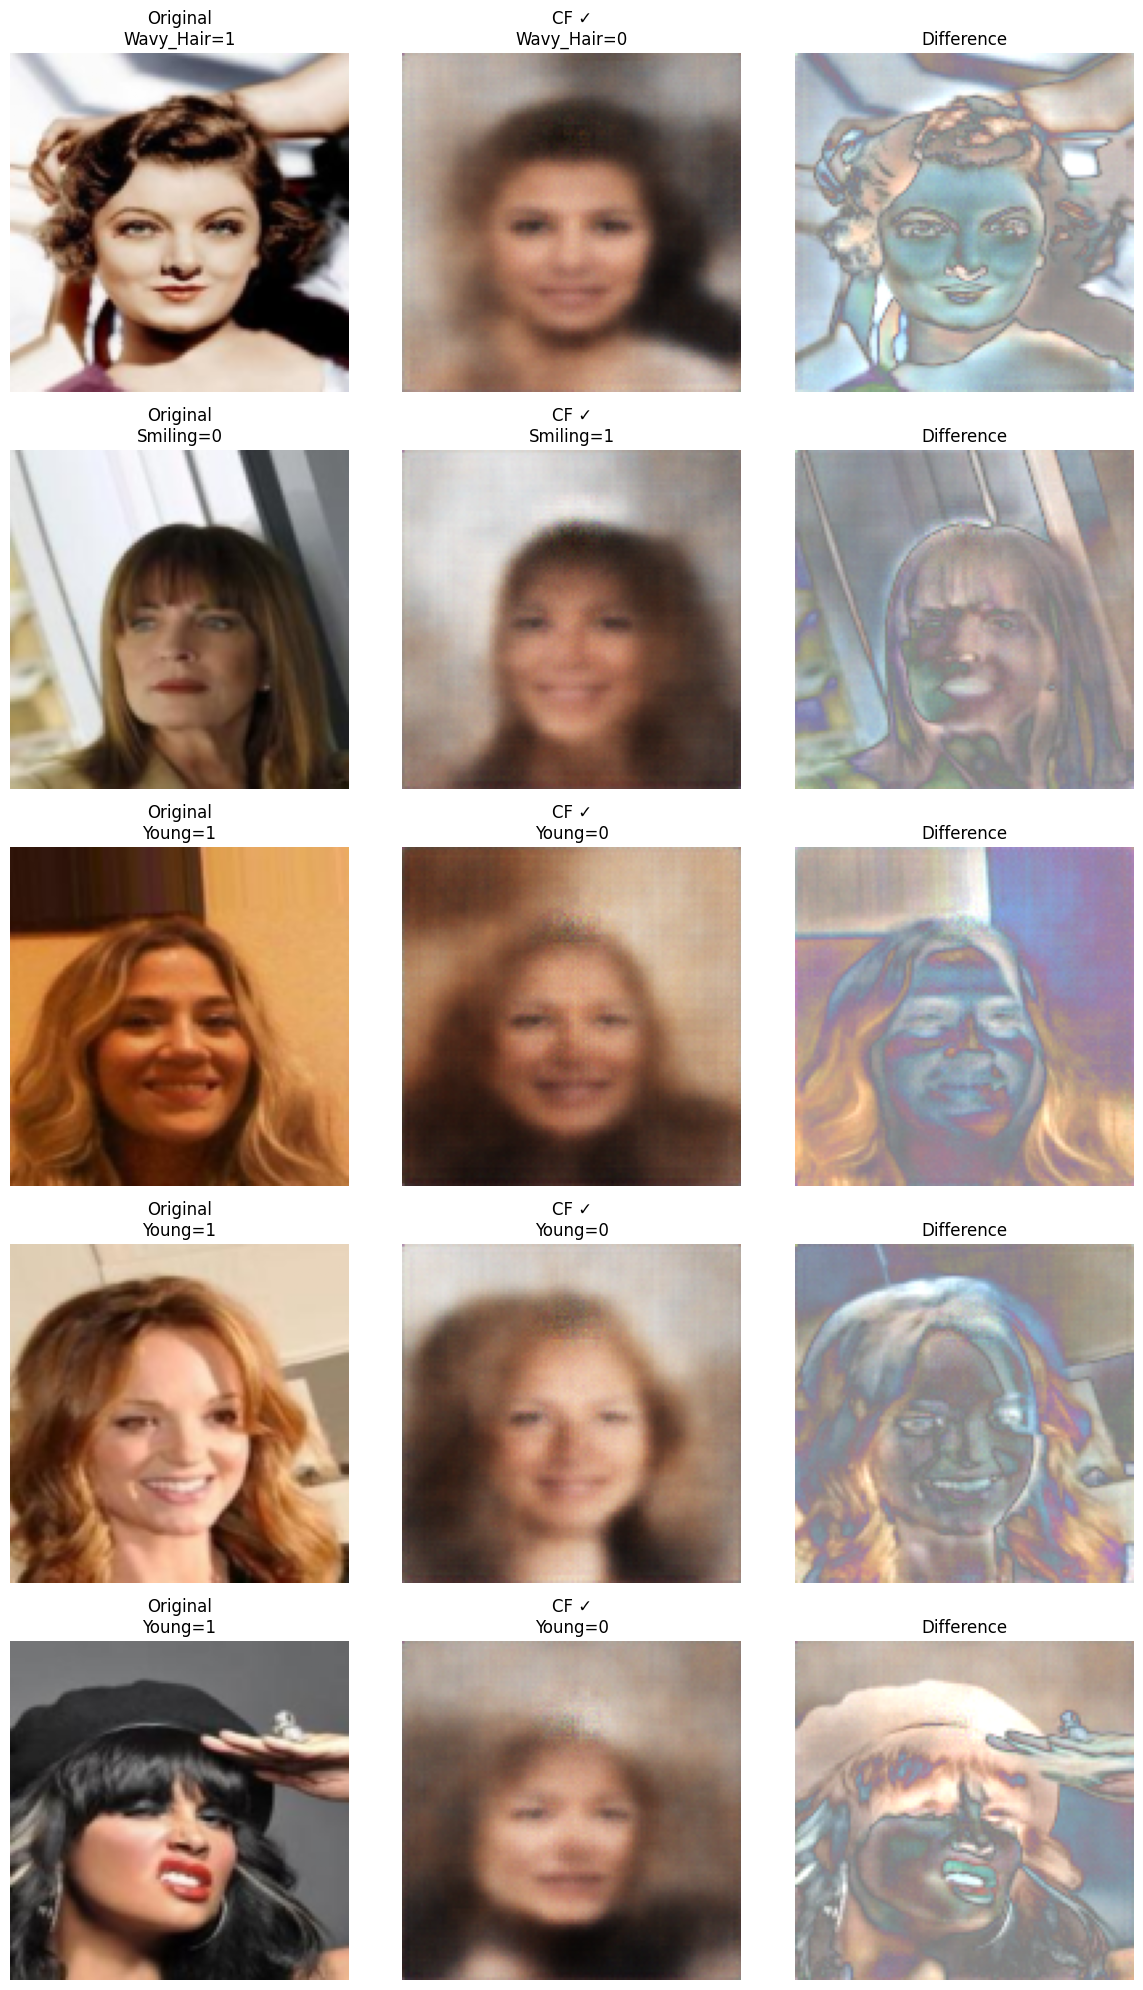

Saved: results/celeba_counterfactual_examples.png

EVALUATION COMPLETE!


In [17]:
"""
CELEBA COUNTERFACTUAL GENERATION - FIXED MODEL COMPATIBILITY
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import pandas as pd
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ATTRIBUTE_NAMES = ['Male', 'Young', 'Smiling', 'Bald', 'Mustache', 'Eyeglasses', 'Wavy_Hair', 'Pale_Skin']
NUM_ATTRIBUTES = 8

os.makedirs('results', exist_ok=True)

# ==============================================================================
# MODEL DEFINITIONS - COMPATIBLE WITH SAVED WEIGHTS
# ==============================================================================

class MultiAttributeCNN(nn.Module):
    def __init__(self, num_attributes=8, dropout=0.5):
        super(MultiAttributeCNN, self).__init__()
        # Using BatchNorm2d to match the saved model
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, num_attributes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class ConditionalBetaVAE(nn.Module):
    def __init__(self, latent_dim=64, num_attributes=8):
        super(ConditionalBetaVAE, self).__init__()
        self.latent_dim = latent_dim

        # Using InstanceNorm2d for VAE (as per your training code)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.InstanceNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)
        self.label_embed = nn.Linear(num_attributes, 32)
        self.fc_decode = nn.Linear(latent_dim + 32, 256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 8, 8)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.InstanceNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        label_emb = self.label_embed(labels)
        z_cond = torch.cat([z, label_emb], dim=1)
        h = self.fc_decode(z_cond)
        return self.decoder(h)

    def forward(self, x, labels):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, labels)
        return recon, mu, logvar


class VGGPerceptualLoss(nn.Module):
    def __init__(self, layers=['relu1_2', 'relu2_2', 'relu3_3'], device='cuda'):
        super(VGGPerceptualLoss, self).__init__()
        vgg = models.vgg16(weights='IMAGENET1K_V1').features
        for param in vgg.parameters():
            param.requires_grad = False

        self.vgg = vgg.to(device).eval()
        self.device = device
        self.layer_mapping = {'relu1_2': 3, 'relu2_2': 8, 'relu3_3': 15}
        self.target_layers = [self.layer_mapping[l] for l in layers]

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1))

    def normalize_vgg_input(self, x):
        x = (x + 1) / 2
        x = (x - self.mean) / self.std
        return x

    def extract_features(self, x):
        x = self.normalize_vgg_input(x)
        features = []
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.target_layers:
                features.append(x)
        return features

    def forward(self, x, y):
        x_features = self.extract_features(x)
        y_features = self.extract_features(y)
        loss = 0.0
        for fx, fy in zip(x_features, y_features):
            loss += F.mse_loss(fx, fy)
        return loss / len(x_features)

# ==============================================================================
# COUNTERFACTUAL GENERATOR
# ==============================================================================

class CounterfactualGenerator:
    def __init__(self, vae, cnn, perceptual_loss, device='cuda'):
        self.vae = vae.to(device).eval()
        self.cnn = cnn.to(device).eval()
        self.perceptual_loss = perceptual_loss.to(device)
        self.device = device

        for param in self.vae.parameters():
            param.requires_grad = False
        for param in self.cnn.parameters():
            param.requires_grad = False

    def generate(self, image, source_attrs, target_attr_idx, target_value,
                 w_target=10.0, w_preserve=2.0, w_perceptual=5.0, w_minimal=0.5,
                 lr=0.03, steps=300, verbose=False):

        # Ensure all tensors are on the correct device
        image = image.to(self.device)
        source_attrs = source_attrs.to(self.device)

        # Encode to latent space
        with torch.no_grad():
            mu, logvar = self.vae.encode(image)
            z_original = mu.clone()

        # Create target attributes
        target_attrs = source_attrs.clone()
        target_attrs[0, target_attr_idx] = target_value

        # Optimize latent code
        z = mu.clone().detach().requires_grad_(True)
        optimizer = optim.Adam([z], lr=lr)

        if verbose:
            pbar = tqdm(range(steps), desc="Optimizing")
        else:
            pbar = range(steps)

        for step in pbar:
            optimizer.zero_grad()

            # Decode
            cf_image = self.vae.decode(z, target_attrs)

            # Get predictions
            cf_pred = torch.sigmoid(self.cnn(cf_image))

            # 1. Target loss - flip target attribute
            target_tensor = torch.tensor([target_value], device=self.device, dtype=torch.float32)
            loss_target = F.binary_cross_entropy(
                cf_pred[:, target_attr_idx],
                target_tensor
            )

            # 2. Preserve loss - maintain other attributes
            non_target_mask = torch.ones_like(source_attrs, device=self.device)
            non_target_mask[:, target_attr_idx] = 0
            loss_preserve = F.binary_cross_entropy(
                cf_pred * non_target_mask,
                source_attrs * non_target_mask
            )

            # 3. Perceptual loss
            loss_perceptual = self.perceptual_loss(cf_image, image)

            # 4. Minimal loss
            loss_minimal = F.mse_loss(z, z_original)

            # Total loss
            loss = (w_target * loss_target +
                    w_preserve * loss_preserve +
                    w_perceptual * loss_perceptual +
                    w_minimal * loss_minimal)

            loss.backward()
            optimizer.step()

            if verbose and step % 50 == 0:
                pbar.set_postfix({
                    'target': f'{loss_target.item():.3f}',
                    'perc': f'{loss_perceptual.item():.3f}',
                    'total': f'{loss.item():.2f}'
                })

        # Generate final counterfactual
        with torch.no_grad():
            cf_image = self.vae.decode(z, target_attrs)
            cf_pred = torch.sigmoid(self.cnn(cf_image))
            cf_attrs = (cf_pred > 0.5).float()

        # Compute metrics
        metrics = {
            'flip_success': int(cf_attrs[0, target_attr_idx] == target_value),
            'predicted_attr': int(cf_attrs[0, target_attr_idx]),
            'target_attr_idx': target_attr_idx,
            'target_value': int(target_value),
            'final_confidence': cf_pred[0, target_attr_idx].item(),
        }

        return cf_image, metrics

# ==============================================================================
# SMART MODEL LOADING FUNCTION
# ==============================================================================

def load_model_with_flexibility(model, model_path, device):
    """Load model weights with flexibility for architecture changes"""
    print(f"Loading model from {model_path}...")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")

    # Load the saved state dict
    saved_state_dict = torch.load(model_path, map_location=device)
    model_state_dict = model.state_dict()

    # Filter out unexpected keys and keep only matching ones
    filtered_state_dict = {}
    missing_keys = []
    unexpected_keys = []

    for key, value in saved_state_dict.items():
        if key in model_state_dict:
            if model_state_dict[key].shape == value.shape:
                filtered_state_dict[key] = value
            else:
                missing_keys.append(f"{key} (shape mismatch: model {model_state_dict[key].shape} vs saved {value.shape})")
        else:
            unexpected_keys.append(key)

    # Also check for keys in model that are not in saved
    for key in model_state_dict.keys():
        if key not in saved_state_dict:
            missing_keys.append(key)

    # Load the filtered state dict
    model.load_state_dict(filtered_state_dict, strict=False)

    print(f"✓ Loaded {len(filtered_state_dict)}/{len(saved_state_dict)} parameters")
    if missing_keys:
        print(f"⚠ Missing keys: {len(missing_keys)}")
    if unexpected_keys:
        print(f"⚠ Unexpected keys: {len(unexpected_keys)}")

    return model

# ==============================================================================
# EVALUATION METRICS
# ==============================================================================

def compute_ssim_score(img1, img2):
    from skimage.metrics import structural_similarity as ssim

    if img1.is_cuda:
        img1 = img1.cpu()
    if img2.is_cuda:
        img2 = img2.cpu()

    img1_np = img1.squeeze(0).detach().numpy()
    img2_np = img2.squeeze(0).detach().numpy()
    img1_np = np.transpose(img1_np, (1, 2, 0))
    img2_np = np.transpose(img2_np, (1, 2, 0))
    img1_np = (img1_np + 1) / 2
    img2_np = (img2_np + 1) / 2

    return ssim(img1_np, img2_np, channel_axis=2, data_range=1.0)


def evaluate_counterfactuals(generator, test_images, test_labels,
                             n_samples=100, seed=42):

    print("\n" + "="*70)
    print("EVALUATING COUNTERFACTUALS WITH PERCEPTUAL LOSS")
    print("="*70)

    torch.manual_seed(seed)
    np.random.seed(seed)

    indices = np.random.choice(len(test_images), n_samples, replace=False)

    results = {
        'flip_success': [],
        'ssim_scores': [],
        'l2_distances': [],
        'perceptual_distances': [],
        'confidence_scores': [],
        'per_attribute_success': {attr: [] for attr in ATTRIBUTE_NAMES}
    }

    for idx in tqdm(indices, desc="Generating CFs"):
        image = test_images[idx].unsqueeze(0)
        attrs = test_labels[idx].unsqueeze(0)

        # Choose random target attribute
        target_attr_idx = np.random.randint(0, NUM_ATTRIBUTES)
        original_value = attrs[0, target_attr_idx].item()
        target_value = 1.0 if original_value == 0 else 0.0

        try:
            # Generate counterfactual
            cf_image, metrics = generator.generate(
                image, attrs, target_attr_idx, target_value,
                w_target=10.0, w_preserve=2.0, w_perceptual=5.0, w_minimal=0.5,
                steps=300, verbose=False
            )

            # Compute metrics
            results['flip_success'].append(metrics['flip_success'])
            results['confidence_scores'].append(metrics['final_confidence'])

            ssim_score = compute_ssim_score(image, cf_image)
            results['ssim_scores'].append(ssim_score)

            l2_dist = F.mse_loss(image.cpu(), cf_image.cpu()).item()
            results['l2_distances'].append(l2_dist)

            perc_dist = generator.perceptual_loss(cf_image, image).item()
            results['perceptual_distances'].append(perc_dist)

            # Per-attribute tracking
            attr_name = ATTRIBUTE_NAMES[target_attr_idx]
            results['per_attribute_success'][attr_name].append(metrics['flip_success'])

        except Exception as e:
            print(f"Error at {idx}: {e}")
            continue

    # Print results
    print("\n" + "-"*70)
    print("RESULTS:")
    print("-"*70)
    print(f"Flip Success Rate: {np.mean(results['flip_success'])*100:.1f}%")
    print(f"Average Confidence: {np.mean(results['confidence_scores']):.3f}")
    print(f"\nVisual Quality Metrics:")
    print(f"  SSIM: {np.mean(results['ssim_scores']):.3f} ± {np.std(results['ssim_scores']):.3f}")
    print(f"  L2: {np.mean(results['l2_distances']):.4f} ± {np.std(results['l2_distances']):.4f}")
    print(f"  Perceptual: {np.mean(results['perceptual_distances']):.4f} ± {np.std(results['perceptual_distances']):.4f}")

    print(f"\nPer-Attribute Success Rates:")
    for attr in ATTRIBUTE_NAMES:
        if results['per_attribute_success'][attr]:
            success = np.mean(results['per_attribute_success'][attr]) * 100
            n = len(results['per_attribute_success'][attr])
            print(f"  {attr:<15}: {success:>5.1f}% (n={n})")

    return results

# ==============================================================================
# VISUALIZATION
# ==============================================================================

def visualize_counterfactuals(generator, test_images, test_labels, n_examples=5):
    """Visualize original vs counterfactual"""

    fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4*n_examples))

    for i in range(n_examples):
        idx = np.random.randint(0, len(test_images))
        image = test_images[idx].unsqueeze(0)
        attrs = test_labels[idx].unsqueeze(0)

        target_attr_idx = np.random.randint(0, NUM_ATTRIBUTES)
        original_value = attrs[0, target_attr_idx].item()
        target_value = 1.0 if original_value == 0 else 0.0

        cf_image, metrics = generator.generate(
            image, attrs, target_attr_idx, target_value,
            w_target=10.0, w_preserve=2.0, w_perceptual=5.0, w_minimal=0.5,
            steps=300
        )

        diff = torch.abs(cf_image - image)

        def tensor_to_img(t):
            t = (t + 1) / 2
            return np.clip(np.transpose(t.squeeze(0).detach().cpu().numpy(), (1, 2, 0)), 0, 1)

        axes[i, 0].imshow(tensor_to_img(image))
        axes[i, 0].set_title(f"Original\n{ATTRIBUTE_NAMES[target_attr_idx]}={int(original_value)}")
        axes[i, 0].axis('off')

        success = "✓" if metrics['flip_success'] else "✗"
        axes[i, 1].imshow(tensor_to_img(cf_image))
        axes[i, 1].set_title(f"CF {success}\n{ATTRIBUTE_NAMES[target_attr_idx]}={int(target_value)}")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(tensor_to_img(diff))
        axes[i, 2].set_title("Difference")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('results/celeba_counterfactual_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: results/celeba_counterfactual_examples.png")

# ==============================================================================
# DATASET
# ==============================================================================

class CelebADataset(Dataset):
    def __init__(self, root_dir, attr_file, transform=None, max_samples=5000):
        self.root_dir = root_dir
        self.transform = transform
        self.attr_df = pd.read_csv(attr_file)
        self.img_dir = self._find_image_directory()

        self.valid_indices = []
        self.image_paths = []
        self.attributes = []

        attr_map = {
            'Male': 'Male', 'Young': 'Young', 'Smiling': 'Smiling',
            'Bald': 'Bald', 'Mustache': 'Mustache', 'Eyeglasses': 'Eyeglasses',
            'Wavy_Hair': 'Wavy_Hair', 'Pale_Skin': 'Pale_Skin'
        }

        print(f"Loading {max_samples} images...")
        for idx in tqdm(range(min(len(self.attr_df), max_samples))):
            img_name = self.attr_df.iloc[idx]['image_id']
            img_path = os.path.join(self.img_dir, img_name)

            if os.path.exists(img_path):
                self.valid_indices.append(idx)
                self.image_paths.append(img_path)

                attr_row = self.attr_df.iloc[idx]
                attributes = torch.tensor([
                    (attr_row[attr_map[name]] + 1) // 2
                    for name in ATTRIBUTE_NAMES
                ], dtype=torch.float32)
                self.attributes.append(attributes)

        print(f"✓ Loaded {len(self.valid_indices)} images")

    def _find_image_directory(self):
        possible_paths = [
            os.path.join(self.root_dir, 'images', 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'images', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba'),
        ]
        for path in possible_paths:
            if os.path.exists(path) and any(f.endswith('.jpg') for f in os.listdir(path)):
                return path
        raise FileNotFoundError("Image directory not found")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        attr = self.attributes[idx]
        return img, attr

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

if __name__ == "__main__":
    print("Loading models and data...")

    # Load test data with transform
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    testset = CelebADataset(
        root_dir='/content/celeba_data',
        attr_file='/content/celeba_data/list_attr_celeba.csv',
        transform=transform,
        max_samples=5000
    )

    # Create DataLoader to handle batching and transformation
    testloader = torch.utils.data.DataLoader(
        testset,
        batch_size=len(testset),  # Load entire dataset at once
        shuffle=False,
        num_workers=2
    )

    # Get all test data in one batch and move to device
    test_images, test_labels = next(iter(testloader))
    test_images = test_images.to(device)
    test_labels = test_labels.to(device)

    print(f"Loaded test images: {test_images.shape} on {test_images.device}")
    print(f"Loaded test labels: {test_labels.shape} on {test_labels.device}")

    # Load models with flexible loading
    print("Loading CNN...")
    cnn = MultiAttributeCNN()
    cnn = load_model_with_flexibility(cnn, 'models/celeba_cnn_best.pth', device)
    cnn.eval()

    print("Loading VAE...")
    vae = ConditionalBetaVAE(latent_dim=64, num_attributes=8)
    vae = load_model_with_flexibility(vae, 'models/celeba_vae_final.pth', device)
    vae.eval()

    print("Loading VGG for perceptual loss...")
    perceptual_loss = VGGPerceptualLoss(device=device)

    print("\nCreating counterfactual generator...")
    generator = CounterfactualGenerator(vae, cnn, perceptual_loss, device=device)

    # Test with a single example first
    print("\nTesting with single example...")
    test_idx = 0
    test_image = test_images[test_idx:test_idx+1]
    test_attr = test_labels[test_idx:test_idx+1]

    target_attr_idx = 0  # Male attribute
    original_value = test_attr[0, target_attr_idx].item()
    target_value = 1.0 if original_value == 0 else 0.0

    print(f"Testing attribute flip: {ATTRIBUTE_NAMES[target_attr_idx]} from {original_value} to {target_value}")

    cf_image, metrics = generator.generate(
        test_image, test_attr, target_attr_idx, target_value,
        w_target=10.0, w_preserve=2.0, w_perceptual=5.0, w_minimal=0.5,
        steps=100, verbose=True
    )

    print(f"Single test result: Success={metrics['flip_success']}, Confidence={metrics['final_confidence']:.3f}")

    # Evaluate on larger set
    results = evaluate_counterfactuals(
        generator, test_images, test_labels,
        n_samples=50, seed=42  # Reduced for faster testing
    )

    # Save results
    with open('results/celeba_evaluation_results.pkl', 'wb') as f:
        pickle.dump(results, f)
    print("\nSaved: results/celeba_evaluation_results.pkl")

    # Visualize
    print("\nGenerating visualizations...")
    visualize_counterfactuals(generator, test_images, test_labels, n_examples=5)

    print("\n" + "="*70)
    print("EVALUATION COMPLETE!")
    print("="*70)

Using device: cuda
Loading models and data...
Loading 2000 images...


100%|██████████| 2000/2000 [00:00<00:00, 7019.88it/s]

✓ Loaded 2000 images


Loaded test images: torch.Size([2000, 3, 128, 128]) on cuda:0
Loaded test labels: torch.Size([2000, 8]) on cuda:0
Loading CNN...
Loading model from models/celeba_cnn_best.pth...
✓ Loaded 25/25 parameters
Loading VAE...
Loading model from models/celeba_vae_final.pth...
✓ Loaded 24/24 parameters
Loading VGG for perceptual loss...

Creating generators...

RUNNING COMPREHENSIVE COMPARISON

COMPARING OLD vs NEW METHOD (CelebA)


Comparing: 100%|██████████| 50/50 [03:28<00:00,  4.17s/it]


...


Testing w_perceptual = 5.0


w=5.0: 100%|██████████| 20/20 [00:59<00:00,  2.97s/it]



Testing w_perceptual = 10.0


w=10.0: 100%|██████████| 20/20 [00:59<00:00,  2.96s/it]



----------------------------------------------------------------------
ABLATION RESULTS:
----------------------------------------------------------------------
w_perceptual    Flip Rate       SSIM            Perc Dist      
----------------------------------------------------------------------
0.0                      85.0%         0.372        8.8980
1.0                      85.0%         0.418        8.1088
3.0                      60.0%         0.420        7.7067
5.0                      70.0%         0.437        7.4103
10.0                     75.0%         0.443        7.2524

Generating visual comparisons...


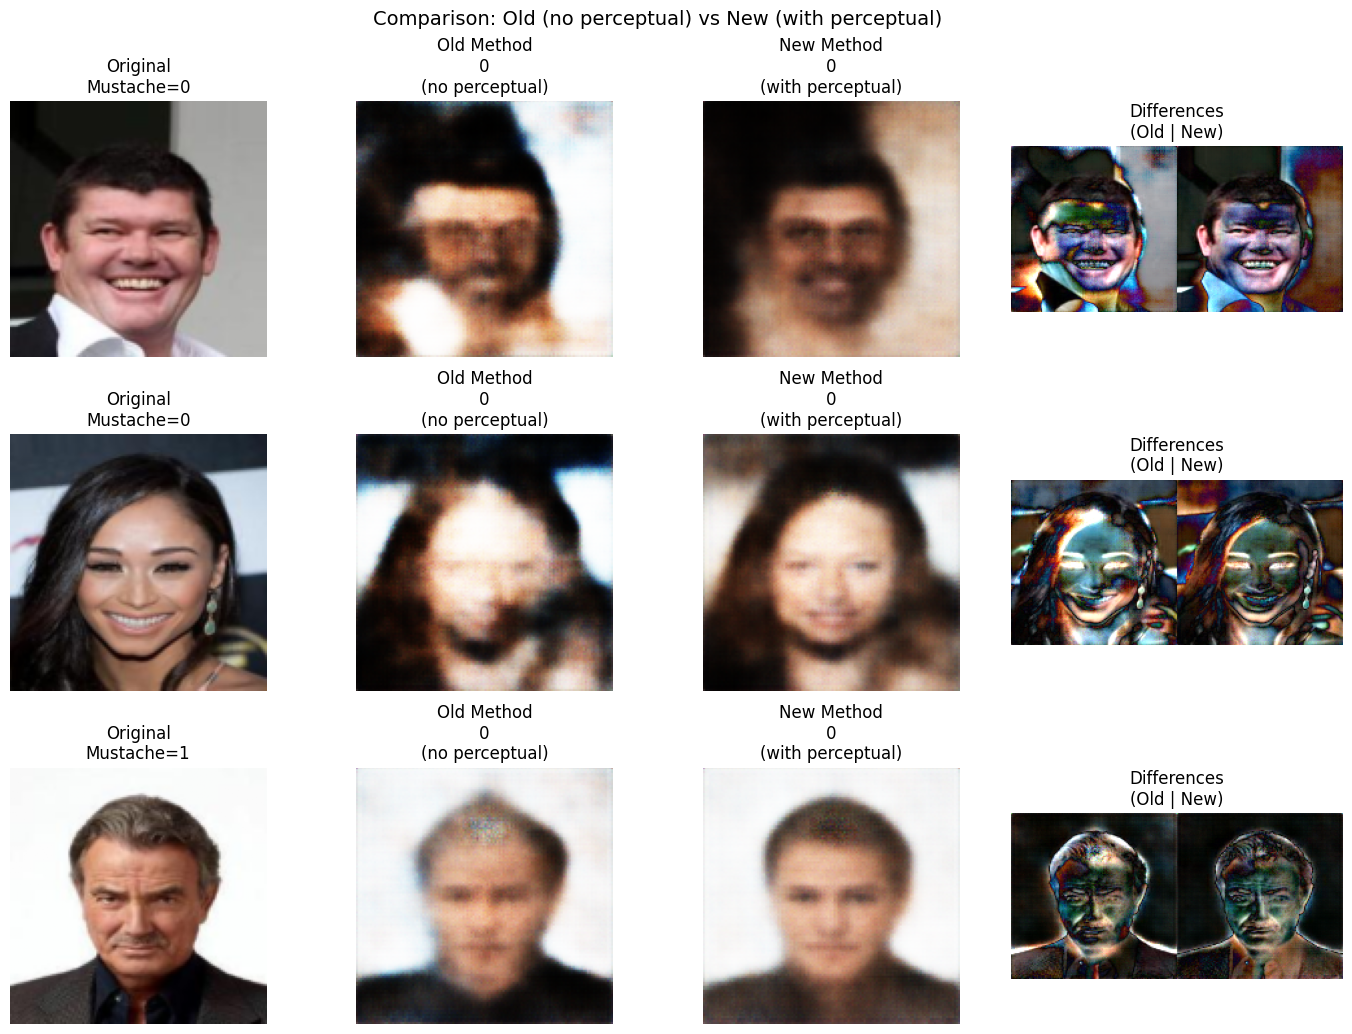

Saved: results/celeba_old_vs_new_comparison.png

ANALYSIS COMPLETE!
Saved results to: results/celeba_comparison_results.pkl
Saved visualization to: results/celeba_old_vs_new_comparison.png


In [18]:
"""
CELEBA ABLATION STUDY
Part 3: EXACT same as CIFAR-10
Comparing old vs new method, ablation on perceptual weight
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
from skimage.metrics import structural_similarity as ssim
import pandas as pd
from PIL import Image
import os
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ATTRIBUTE_NAMES = ['Male', 'Young', 'Smiling', 'Bald', 'Mustache', 'Eyeglasses', 'Wavy_Hair', 'Pale_Skin']
NUM_ATTRIBUTES = 8

os.makedirs('results', exist_ok=True)

# ==============================================================================
# MODEL DEFINITIONS (Same as before)
# ==============================================================================

class MultiAttributeCNN(nn.Module):
    def __init__(self, num_attributes=8, dropout=0.5):
        super(MultiAttributeCNN, self).__init__()
        # Using BatchNorm2d to match the saved model
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, num_attributes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class ConditionalBetaVAE(nn.Module):
    def __init__(self, latent_dim=64, num_attributes=8):
        super(ConditionalBetaVAE, self).__init__()
        self.latent_dim = latent_dim

        # Using InstanceNorm2d for VAE (as per your training code)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.InstanceNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)
        self.label_embed = nn.Linear(num_attributes, 32)
        self.fc_decode = nn.Linear(latent_dim + 32, 256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 8, 8)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.InstanceNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        label_emb = self.label_embed(labels)
        z_cond = torch.cat([z, label_emb], dim=1)
        h = self.fc_decode(z_cond)
        return self.decoder(h)

    def forward(self, x, labels):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, labels)
        return recon, mu, logvar


class VGGPerceptualLoss(nn.Module):
    def __init__(self, layers=['relu1_2', 'relu2_2', 'relu3_3'], device='cuda'):
        super(VGGPerceptualLoss, self).__init__()
        vgg = models.vgg16(weights='IMAGENET1K_V1').features
        for param in vgg.parameters():
            param.requires_grad = False

        self.vgg = vgg.to(device).eval()
        self.device = device
        self.layer_mapping = {'relu1_2': 3, 'relu2_2': 8, 'relu3_3': 15}
        self.target_layers = [self.layer_mapping[l] for l in layers]

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1))

    def normalize_vgg_input(self, x):
        x = (x + 1) / 2
        x = (x - self.mean) / self.std
        return x

    def extract_features(self, x):
        x = self.normalize_vgg_input(x)
        features = []
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.target_layers:
                features.append(x)
        return features

    def forward(self, x, y):
        x_features = self.extract_features(x)
        y_features = self.extract_features(y)
        loss = 0.0
        for fx, fy in zip(x_features, y_features):
            loss += F.mse_loss(fx, fy)
        return loss / len(x_features)

# ==============================================================================
# SMART MODEL LOADING FUNCTION
# ==============================================================================

def load_model_with_flexibility(model, model_path, device):
    """Load model weights with flexibility for architecture changes"""
    print(f"Loading model from {model_path}...")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")

    # Load the saved state dict
    saved_state_dict = torch.load(model_path, map_location=device)
    model_state_dict = model.state_dict()

    # Filter out unexpected keys and keep only matching ones
    filtered_state_dict = {}
    missing_keys = []
    unexpected_keys = []

    for key, value in saved_state_dict.items():
        if key in model_state_dict:
            if model_state_dict[key].shape == value.shape:
                filtered_state_dict[key] = value
            else:
                missing_keys.append(f"{key} (shape mismatch: model {model_state_dict[key].shape} vs saved {value.shape})")
        else:
            unexpected_keys.append(key)

    # Also check for keys in model that are not in saved
    for key in model_state_dict.keys():
        if key not in saved_state_dict:
            missing_keys.append(key)

    # Load the filtered state dict
    model.load_state_dict(filtered_state_dict, strict=False)

    print(f"✓ Loaded {len(filtered_state_dict)}/{len(saved_state_dict)} parameters")
    if missing_keys:
        print(f"⚠ Missing keys: {len(missing_keys)}")
    if unexpected_keys:
        print(f"⚠ Unexpected keys: {len(unexpected_keys)}")

    return model

# ==============================================================================
# OLD METHOD (WITHOUT PERCEPTUAL LOSS)
# ==============================================================================

class OldCounterfactualGenerator:
    """OLD METHOD: No perceptual loss"""
    def __init__(self, vae, cnn, device='cuda'):
        self.vae = vae.to(device).eval()
        self.cnn = cnn.to(device).eval()
        self.device = device

        for param in self.vae.parameters():
            param.requires_grad = False
        for param in self.cnn.parameters():
            param.requires_grad = False

    def generate(self, image, source_attrs, target_attr_idx, target_value,
                 w_target=10.0, w_preserve=8.0, w_minimal=0.5,
                 lr=0.03, steps=300):

        image = image.to(self.device)
        source_attrs = source_attrs.to(self.device)

        with torch.no_grad():
            mu, logvar = self.vae.encode(image)
            z_original = mu.clone()

        target_attrs = source_attrs.clone()
        target_attrs[0, target_attr_idx] = target_value

        z = mu.clone().detach().requires_grad_(True)
        optimizer = optim.Adam([z], lr=lr)

        for step in range(steps):
            optimizer.zero_grad()
            cf_image = self.vae.decode(z, target_attrs)
            cf_pred = torch.sigmoid(self.cnn(cf_image))

            # OLD LOSS: Only classifier-based
            loss_target = F.binary_cross_entropy(
                cf_pred[:, target_attr_idx],
                torch.tensor([target_value], device=self.device, dtype=torch.float32)
            )

            non_target_mask = torch.ones_like(source_attrs, device=self.device)
            non_target_mask[:, target_attr_idx] = 0
            loss_preserve = F.binary_cross_entropy(
                cf_pred * non_target_mask,
                source_attrs * non_target_mask
            )

            loss_minimal = F.mse_loss(z, z_original)

            loss = w_target * loss_target + w_preserve * loss_preserve + w_minimal * loss_minimal
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            cf_image = self.vae.decode(z, target_attrs)
            cf_pred = torch.sigmoid(self.cnn(cf_image))
            cf_attrs = (cf_pred > 0.5).float()
            pred_class = int(cf_attrs[0, target_attr_idx])

        return cf_image, pred_class

# ==============================================================================
# NEW METHOD (WITH PERCEPTUAL LOSS)
# ==============================================================================

class NewCounterfactualGenerator:
    """NEW METHOD: With perceptual loss"""
    def __init__(self, vae, cnn, perceptual_loss, device='cuda'):
        self.vae = vae.to(device).eval()
        self.cnn = cnn.to(device).eval()
        self.perceptual_loss = perceptual_loss.to(device)
        self.device = device

        for param in self.vae.parameters():
            param.requires_grad = False
        for param in self.cnn.parameters():
            param.requires_grad = False

    def generate(self, image, source_attrs, target_attr_idx, target_value,
                 w_target=10.0, w_preserve=2.0, w_perceptual=5.0, w_minimal=0.5,
                 lr=0.03, steps=300):

        image = image.to(self.device)
        source_attrs = source_attrs.to(self.device)

        with torch.no_grad():
            mu, logvar = self.vae.encode(image)
            z_original = mu.clone()

        target_attrs = source_attrs.clone()
        target_attrs[0, target_attr_idx] = target_value

        z = mu.clone().detach().requires_grad_(True)
        optimizer = optim.Adam([z], lr=lr)

        for step in range(steps):
            optimizer.zero_grad()
            cf_image = self.vae.decode(z, target_attrs)
            cf_pred = torch.sigmoid(self.cnn(cf_image))

            loss_target = F.binary_cross_entropy(
                cf_pred[:, target_attr_idx],
                torch.tensor([target_value], device=self.device, dtype=torch.float32)
            )

            non_target_mask = torch.ones_like(source_attrs, device=self.device)
            non_target_mask[:, target_attr_idx] = 0
            loss_preserve = F.binary_cross_entropy(
                cf_pred * non_target_mask,
                source_attrs * non_target_mask
            )

            # NEW: Perceptual loss
            loss_perceptual = self.perceptual_loss(cf_image, image)

            loss_minimal = F.mse_loss(z, z_original)

            loss = (w_target * loss_target + w_preserve * loss_preserve +
                    w_perceptual * loss_perceptual + w_minimal * loss_minimal)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            cf_image = self.vae.decode(z, target_attrs)
            cf_pred = torch.sigmoid(self.cnn(cf_image))
            cf_attrs = (cf_pred > 0.5).float()
            pred_class = int(cf_attrs[0, target_attr_idx])

        return cf_image, pred_class

# ==============================================================================
# DATASET (Same as before)
# ==============================================================================

class CelebADataset(Dataset):
    def __init__(self, root_dir, attr_file, transform=None, max_samples=5000):
        self.root_dir = root_dir
        self.transform = transform
        self.attr_df = pd.read_csv(attr_file)
        self.img_dir = self._find_image_directory()

        self.valid_indices = []
        self.image_paths = []
        self.attributes = []

        attr_map = {
            'Male': 'Male', 'Young': 'Young', 'Smiling': 'Smiling',
            'Bald': 'Bald', 'Mustache': 'Mustache', 'Eyeglasses': 'Eyeglasses',
            'Wavy_Hair': 'Wavy_Hair', 'Pale_Skin': 'Pale_Skin'
        }

        print(f"Loading {max_samples} images...")
        for idx in tqdm(range(min(len(self.attr_df), max_samples))):
            img_name = self.attr_df.iloc[idx]['image_id']
            img_path = os.path.join(self.img_dir, img_name)

            if os.path.exists(img_path):
                self.valid_indices.append(idx)
                self.image_paths.append(img_path)

                attr_row = self.attr_df.iloc[idx]
                attributes = torch.tensor([
                    (attr_row[attr_map[name]] + 1) // 2
                    for name in ATTRIBUTE_NAMES
                ], dtype=torch.float32)
                self.attributes.append(attributes)

        print(f"✓ Loaded {len(self.valid_indices)} images")

    def _find_image_directory(self):
        possible_paths = [
            os.path.join(self.root_dir, 'images', 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'images', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba'),
        ]
        for path in possible_paths:
            if os.path.exists(path) and any(f.endswith('.jpg') for f in os.listdir(path)):
                return path
        raise FileNotFoundError("Image directory not found")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        attr = self.attributes[idx]
        return img, attr

# ==============================================================================
# UTILITY FUNCTIONS
# ==============================================================================

def compute_ssim_score(img1, img2):
    """Compute SSIM between two images"""
    if img1.is_cuda:
        img1 = img1.cpu()
    if img2.is_cuda:
        img2 = img2.cpu()

    img1_np = img1.squeeze(0).detach().numpy()
    img2_np = img2.squeeze(0).detach().numpy()
    img1_np = np.transpose(img1_np, (1, 2, 0))
    img2_np = np.transpose(img2_np, (1, 2, 0))
    img1_np = (img1_np + 1) / 2
    img2_np = (img2_np + 1) / 2

    return ssim(img1_np, img2_np, channel_axis=2, data_range=1.0)

# ==============================================================================
# COMPARISON
# ==============================================================================

def compare_methods(old_gen, new_gen, perceptual_loss, test_images, test_labels,
                    n_samples=100, seed=42):
    """Compare old vs new method"""
    print("\n" + "="*70)
    print("COMPARING OLD vs NEW METHOD (CelebA)")
    print("="*70)

    torch.manual_seed(seed)
    np.random.seed(seed)

    indices = np.random.choice(len(test_images), n_samples, replace=False)

    old_results = {'flip_success': [], 'ssim': [], 'l2': [], 'perceptual': []}
    new_results = {'flip_success': [], 'ssim': [], 'l2': [], 'perceptual': []}

    for idx in tqdm(indices, desc="Comparing"):
        image = test_images[idx].unsqueeze(0)
        attrs = test_labels[idx].unsqueeze(0)

        target_attr_idx = np.random.randint(0, NUM_ATTRIBUTES)
        original_value = attrs[0, target_attr_idx].item()
        target_value = 1.0 if original_value == 0 else 0.0

        # OLD METHOD
        try:
            old_cf, old_pred = old_gen.generate(image, attrs, target_attr_idx, target_value)
            old_results['flip_success'].append(int(old_pred == target_value))
            old_results['ssim'].append(compute_ssim_score(image, old_cf))
            old_results['l2'].append(F.mse_loss(image.cpu(), old_cf.cpu()).item())
            old_results['perceptual'].append(perceptual_loss(old_cf, image).item())
        except Exception as e:
            print(f"Error in old method at {idx}: {e}")
            continue

        # NEW METHOD
        try:
            new_cf, new_pred = new_gen.generate(image, attrs, target_attr_idx, target_value)
            new_results['flip_success'].append(int(new_pred == target_value))
            new_results['ssim'].append(compute_ssim_score(image, new_cf))
            new_results['l2'].append(F.mse_loss(image.cpu(), new_cf.cpu()).item())
            new_results['perceptual'].append(perceptual_loss(new_cf, image).item())
        except Exception as e:
            print(f"Error in new method at {idx}: {e}")
            continue

    # Print comparison
    print("\n" + "-"*70)
    print("COMPARISON RESULTS:")
    print("-"*70)
    print(f"{'Metric':<30} {'Old Method':<20} {'New Method':<20}")
    print("-"*70)

    old_flip = np.mean(old_results['flip_success']) * 100
    new_flip = np.mean(new_results['flip_success']) * 100
    print(f"{'Flip Success Rate':<30} {old_flip:>18.1f}% {new_flip:>18.1f}%")

    old_ssim = np.mean(old_results['ssim'])
    new_ssim = np.mean(new_results['ssim'])
    print(f"{'SSIM (↑ better)':<30} {old_ssim:>20.3f} {new_ssim:>20.3f}")

    old_l2 = np.mean(old_results['l2'])
    new_l2 = np.mean(new_results['l2'])
    print(f"{'L2 Distance (↓ better)':<30} {old_l2:>20.4f} {new_l2:>20.4f}")

    old_perc = np.mean(old_results['perceptual'])
    new_perc = np.mean(new_results['perceptual'])
    print(f"{'Perceptual Dist (↓ better)':<30} {old_perc:>20.4f} {new_perc:>20.4f}")

    print("\n" + "-"*70)
    print("KEY FINDINGS:")
    print("-"*70)

    if new_ssim > old_ssim:
        print(f"✓ New method: {((new_ssim-old_ssim)/old_ssim*100):.1f}% better SSIM")
    if new_perc < old_perc:
        print(f"✓ New method: {((old_perc-new_perc)/old_perc*100):.1f}% lower perceptual distance")

    return old_results, new_results

# ==============================================================================
# ABLATION STUDY
# ==============================================================================

def ablation_perceptual_weight(new_gen, test_images, test_labels, n_samples=30):
    """Test different perceptual loss weights"""
    print("\n" + "="*70)
    print("ABLATION STUDY: PERCEPTUAL LOSS WEIGHT")
    print("="*70)

    weights = [0.0, 1.0, 3.0, 5.0, 10.0]
    results = {w: {'flip': [], 'ssim': [], 'perceptual': []} for w in weights}

    torch.manual_seed(42)
    indices = np.random.choice(len(test_images), n_samples, replace=False)

    for w_perc in weights:
        print(f"\nTesting w_perceptual = {w_perc}")

        for idx in tqdm(indices, desc=f"w={w_perc}"):
            image = test_images[idx].unsqueeze(0)
            attrs = test_labels[idx].unsqueeze(0)

            target_attr_idx = np.random.randint(0, NUM_ATTRIBUTES)
            original_value = attrs[0, target_attr_idx].item()
            target_value = 1.0 if original_value == 0 else 0.0

            try:
                cf, pred = new_gen.generate(
                    image, attrs, target_attr_idx, target_value,
                    w_target=10.0, w_preserve=2.0,
                    w_perceptual=w_perc, w_minimal=0.5
                )

                results[w_perc]['flip'].append(int(pred == target_value))
                results[w_perc]['ssim'].append(compute_ssim_score(image, cf))
                results[w_perc]['perceptual'].append(
                    new_gen.perceptual_loss(cf, image).item()
                )
            except Exception as e:
                print(f"Error at {idx} with w={w_perc}: {e}")
                continue

    # Print results
    print("\n" + "-"*70)
    print("ABLATION RESULTS:")
    print("-"*70)
    print(f"{'w_perceptual':<15} {'Flip Rate':<15} {'SSIM':<15} {'Perc Dist':<15}")
    print("-"*70)

    for w in weights:
        if results[w]['flip']:  # Check if we have results
            flip = np.mean(results[w]['flip']) * 100
            ssim_val = np.mean(results[w]['ssim'])
            perc = np.mean(results[w]['perceptual'])
            print(f"{w:<15.1f} {flip:>13.1f}% {ssim_val:>13.3f} {perc:>13.4f}")
        else:
            print(f"{w:<15.1f} {'No data':>13} {'No data':>13} {'No data':>13}")

    return results

# ==============================================================================
# VISUALIZATION
# ==============================================================================

def visualize_comparison(old_gen, new_gen, test_images, test_labels, n_examples=3):
    """Show old vs new side-by-side"""
    fig, axes = plt.subplots(n_examples, 4, figsize=(14, 3.5*n_examples))

    for i in range(n_examples):
        idx = np.random.randint(0, min(1000, len(test_images))) + i * 500
        image = test_images[idx].unsqueeze(0)
        attrs = test_labels[idx].unsqueeze(0)

        target_attr_idx = np.random.randint(0, NUM_ATTRIBUTES)
        original_value = attrs[0, target_attr_idx].item()
        target_value = 1.0 if original_value == 0 else 0.0

        # Generate with both methods
        try:
            old_cf, old_pred = old_gen.generate(image, attrs, target_attr_idx, target_value)
            new_cf, new_pred = new_gen.generate(image, attrs, target_attr_idx, target_value)

            def to_img(t):
                t = (t + 1) / 2
                return np.clip(np.transpose(t.squeeze().cpu().numpy(), (1,2,0)), 0, 1)

            # Original
            axes[i, 0].imshow(to_img(image))
            axes[i, 0].set_title(f"Original\n{ATTRIBUTE_NAMES[target_attr_idx]}={int(original_value)}")
            axes[i, 0].axis('off')

            # Old method
            axes[i, 1].imshow(to_img(old_cf))
            axes[i, 1].set_title(f"Old Method\n{int(old_pred)}\n(no perceptual)")
            axes[i, 1].axis('off')

            # New method
            axes[i, 2].imshow(to_img(new_cf))
            axes[i, 2].set_title(f"New Method\n{int(new_pred)}\n(with perceptual)")
            axes[i, 2].axis('off')

            # Difference comparison
            old_diff = torch.abs(old_cf - image).squeeze().cpu()
            new_diff = torch.abs(new_cf - image).squeeze().cpu()
            diff_comparison = torch.cat([old_diff, new_diff], dim=2)
            axes[i, 3].imshow(np.transpose(diff_comparison.numpy(), (1,2,0)))
            axes[i, 3].set_title("Differences\n(Old | New)")
            axes[i, 3].axis('off')
        except Exception as e:
            print(f"Error generating example {i}: {e}")
            continue

    plt.suptitle("Comparison: Old (no perceptual) vs New (with perceptual)", fontsize=14)
    plt.tight_layout()
    plt.savefig('results/celeba_old_vs_new_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: results/celeba_old_vs_new_comparison.png")

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

if __name__ == "__main__":
    print("Loading models and data...")

    # Load test data with transform
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    testset = CelebADataset(
        root_dir='/content/celeba_data',
        attr_file='/content/celeba_data/list_attr_celeba.csv',
        transform=transform,
        max_samples=2000  # Reduced for faster ablation study
    )

    # Create DataLoader to handle batching and transformation
    testloader = torch.utils.data.DataLoader(
        testset,
        batch_size=len(testset),  # Load entire dataset at once
        shuffle=False,
        num_workers=2
    )

    # Get all test data in one batch and move to device
    test_images, test_labels = next(iter(testloader))
    test_images = test_images.to(device)
    test_labels = test_labels.to(device)

    print(f"Loaded test images: {test_images.shape} on {test_images.device}")
    print(f"Loaded test labels: {test_labels.shape} on {test_labels.device}")

    # Load models with flexible loading
    print("Loading CNN...")
    cnn = MultiAttributeCNN()
    cnn = load_model_with_flexibility(cnn, 'models/celeba_cnn_best.pth', device)
    cnn.eval()

    print("Loading VAE...")
    vae = ConditionalBetaVAE(latent_dim=64, num_attributes=8)
    vae = load_model_with_flexibility(vae, 'models/celeba_vae_final.pth', device)
    vae.eval()

    print("Loading VGG for perceptual loss...")
    perceptual_loss = VGGPerceptualLoss(device=device)

    # Create generators
    print("\nCreating generators...")
    old_generator = OldCounterfactualGenerator(vae, cnn, device=device)
    new_generator = NewCounterfactualGenerator(vae, cnn, perceptual_loss, device=device)

    # Run comparisons
    print("\n" + "="*70)
    print("RUNNING COMPREHENSIVE COMPARISON")
    print("="*70)

    # 1. Direct comparison
    old_results, new_results = compare_methods(
        old_generator, new_generator, perceptual_loss,
        test_images, test_labels, n_samples=50  # Reduced for faster testing
    )

    # 2. Ablation study
    ablation_results = ablation_perceptual_weight(
        new_generator, test_images, test_labels, n_samples=20  # Reduced for faster testing
    )

    # 3. Visual comparison
    print("\nGenerating visual comparisons...")
    visualize_comparison(
        old_generator, new_generator,
        test_images, test_labels, n_examples=3  # Reduced for faster testing
    )

    # Save all results
    all_results = {
        'old_method': old_results,
        'new_method': new_results,
        'ablation': ablation_results
    }

    with open('results/celeba_comparison_results.pkl', 'wb') as f:
        pickle.dump(all_results, f)

    print("\n" + "="*70)
    print("ANALYSIS COMPLETE!")
    print("="*70)
    print("Saved results to: results/celeba_comparison_results.pkl")
    print("Saved visualization to: results/celeba_old_vs_new_comparison.png")

Using device: cuda
Loading models and data...
Loading 2000 images...


100%|██████████| 2000/2000 [00:00<00:00, 7045.46it/s]

✓ Loaded 2000 images


Loaded test images: torch.Size([2000, 3, 128, 128])
Loaded test labels: torch.Size([2000, 8])
Loading CNN...
Loading model from models/celeba_cnn_best.pth...
✓ Loaded 25/25 parameters
Loading VAE...
Loading model from models/celeba_vae_final.pth...
✓ Loaded 24/24 parameters
Loading VGG for perceptual loss...

Creating counterfactual generator...

[1/3] Per-attribute analysis...

EVALUATION 1: PER-ATTRIBUTE PERFORMANCE

Processing: Male


Male: 100%|██████████| 20/20 [00:39<00:00,  1.98s/it]


...

Eyeglasses: 100%|██████████| 20/20 [00:39<00:00,  1.98s/it]



Processing: Wavy_Hair


Wavy_Hair: 100%|██████████| 20/20 [00:39<00:00,  1.99s/it]



Processing: Pale_Skin


Pale_Skin: 100%|██████████| 20/20 [00:39<00:00,  1.99s/it]


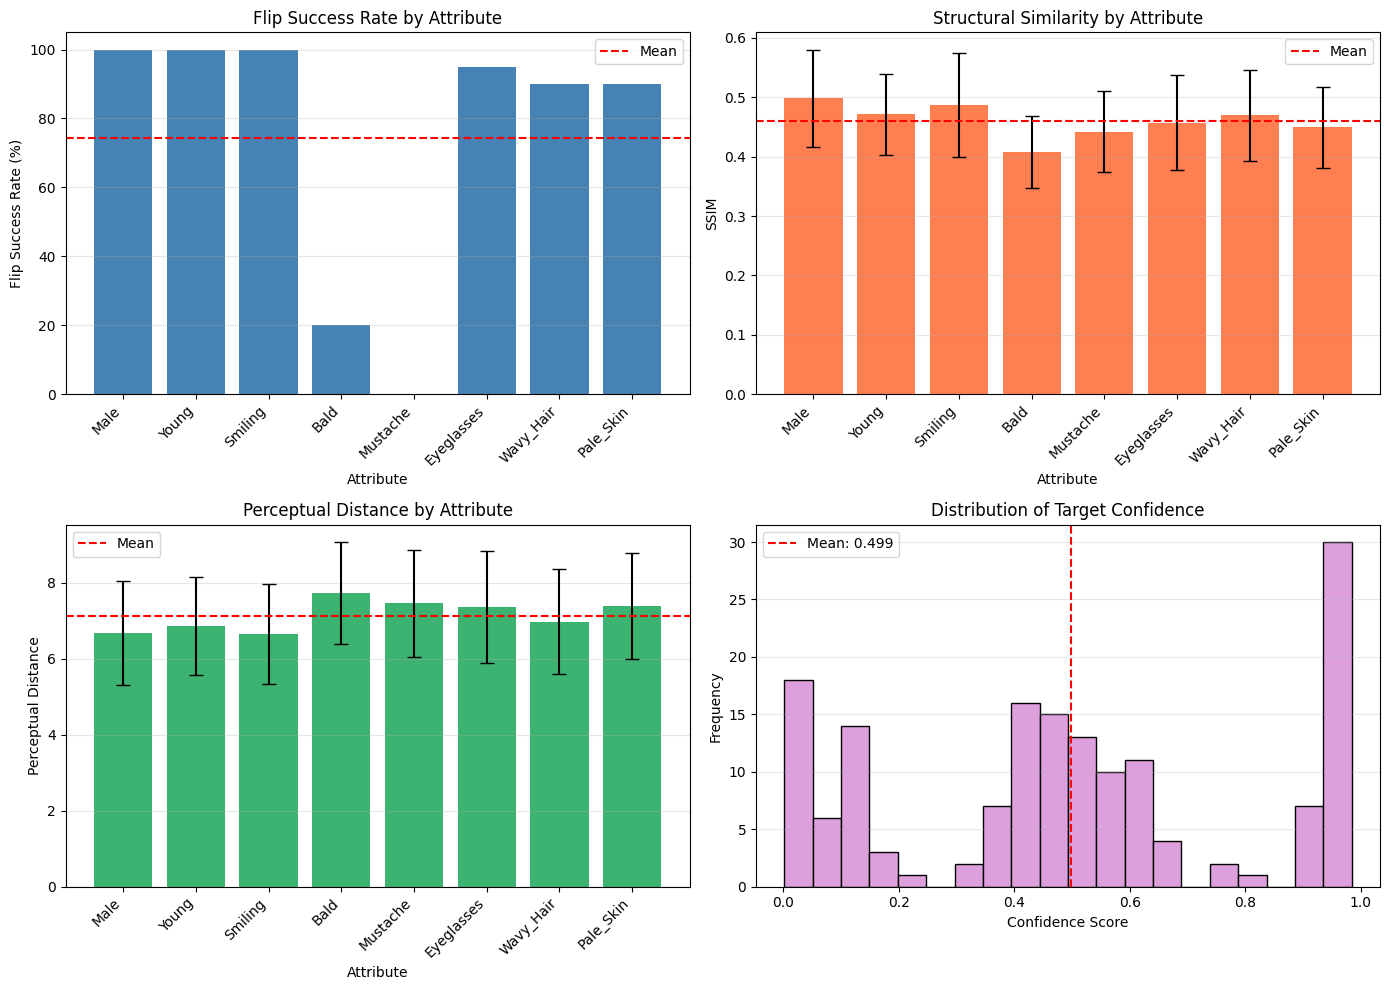


Per-Attribute Summary:
----------------------------------------------------------------------
Attribute            Flip Rate    SSIM         Perc Dist   
----------------------------------------------------------------------
Male                      100.0%      0.498       6.661
Young                     100.0%      0.472       6.857
Smiling                   100.0%      0.487       6.654
Bald                       20.0%      0.408       7.725
Mustache                    0.0%      0.442       7.455
Eyeglasses                 95.0%      0.457       7.346
Wavy_Hair                  90.0%      0.470       6.974
Pale_Skin                  90.0%      0.449       7.376

[2/3] Confidence-distance trade-off...

EVALUATION 2: CONFIDENCE VS DISTANCE TRADE-OFF


Generating samples: 100%|██████████| 80/80 [02:38<00:00,  1.99s/it]


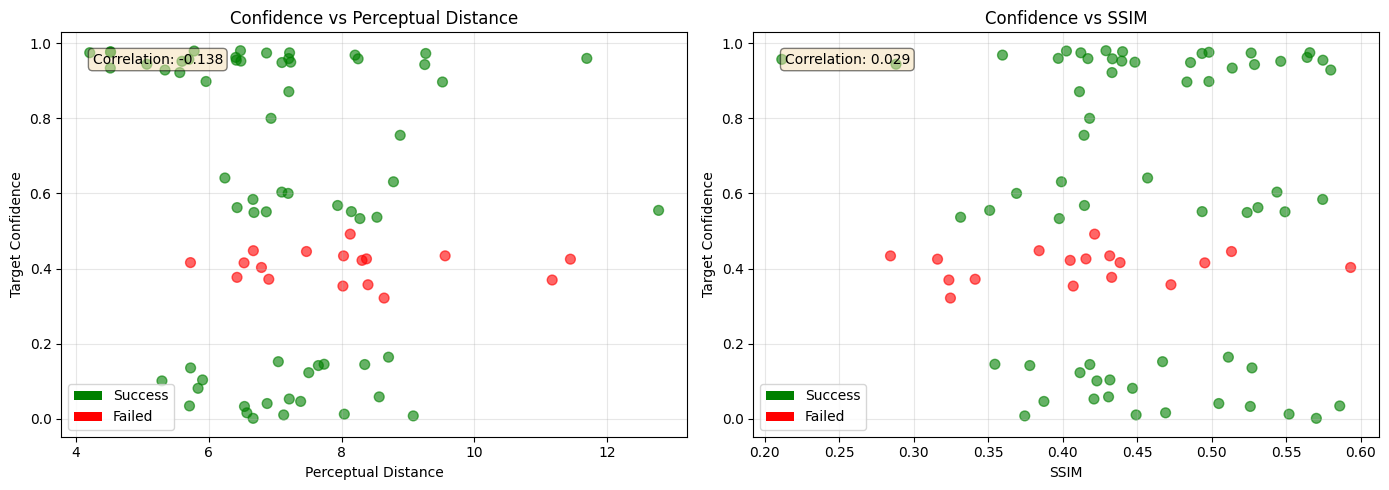


[3/3] Statistical tests...

EVALUATION 3: STATISTICAL SIGNIFICANCE TESTS

Paired T-Tests:
----------------------------------------------------------------------

SSIM:
  t-statistic: -10.2399
  p-value: 9.1094e-14
  Cohen's d: 1.0166
  → Statistically significant (p < 0.05)

Perceptual Distance:
  t-statistic: 18.9325
  p-value: 3.5040e-24
  Cohen's d: -1.3401
  → Statistically significant (p < 0.05)

ALL EVALUATIONS COMPLETE!
Saved results to: results/celeba_additional_evaluations.pkl
Saved visualizations to:
  - results/celeba_per_attribute_analysis.png
  - results/celeba_confidence_distance_tradeoff.png


In [19]:
"""
CELEBA ADDITIONAL EVALUATIONS
Part 4: EXACT same as CIFAR-10 methodology
Per-attribute analysis, confidence-distance trade-off, statistical tests
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
from scipy import stats
from skimage.metrics import structural_similarity as ssim
import pandas as pd
from PIL import Image
import os
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ATTRIBUTE_NAMES = ['Male', 'Young', 'Smiling', 'Bald', 'Mustache', 'Eyeglasses', 'Wavy_Hair', 'Pale_Skin']
NUM_ATTRIBUTES = 8

os.makedirs('results', exist_ok=True)

# ==============================================================================
# MODEL DEFINITIONS (Same as before)
# ==============================================================================

class MultiAttributeCNN(nn.Module):
    def __init__(self, num_attributes=8, dropout=0.5):
        super(MultiAttributeCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, num_attributes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class ConditionalBetaVAE(nn.Module):
    def __init__(self, latent_dim=64, num_attributes=8):
        super(ConditionalBetaVAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.InstanceNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)
        self.label_embed = nn.Linear(num_attributes, 32)
        self.fc_decode = nn.Linear(latent_dim + 32, 256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 8, 8)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.InstanceNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        label_emb = self.label_embed(labels)
        z_cond = torch.cat([z, label_emb], dim=1)
        h = self.fc_decode(z_cond)
        return self.decoder(h)

    def forward(self, x, labels):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, labels)
        return recon, mu, logvar


class VGGPerceptualLoss(nn.Module):
    def __init__(self, layers=['relu1_2', 'relu2_2', 'relu3_3'], device='cuda'):
        super(VGGPerceptualLoss, self).__init__()
        vgg = models.vgg16(weights='IMAGENET1K_V1').features
        for param in vgg.parameters():
            param.requires_grad = False

        self.vgg = vgg.to(device).eval()
        self.device = device
        self.layer_mapping = {'relu1_2': 3, 'relu2_2': 8, 'relu3_3': 15}
        self.target_layers = [self.layer_mapping[l] for l in layers]

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1))

    def normalize_vgg_input(self, x):
        x = (x + 1) / 2
        x = (x - self.mean) / self.std
        return x

    def extract_features(self, x):
        x = self.normalize_vgg_input(x)
        features = []
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.target_layers:
                features.append(x)
        return features

    def forward(self, x, y):
        x_features = self.extract_features(x)
        y_features = self.extract_features(y)
        loss = 0.0
        for fx, fy in zip(x_features, y_features):
            loss += F.mse_loss(fx, fy)
        return loss / len(x_features)

# ==============================================================================
# COUNTERFACTUAL GENERATOR (Updated for additional metrics)
# ==============================================================================

class CounterfactualGenerator:
    def __init__(self, vae, cnn, perceptual_loss, device='cuda'):
        self.vae = vae.to(device).eval()
        self.cnn = cnn.to(device).eval()
        self.perceptual_loss = perceptual_loss.to(device)
        self.device = device

        for param in self.vae.parameters():
            param.requires_grad = False
        for param in self.cnn.parameters():
            param.requires_grad = False

    def generate(self, image, source_attrs, target_attr_idx, target_value,
                 w_target=10.0, w_preserve=2.0, w_perceptual=5.0, w_minimal=0.5,
                 lr=0.03, steps=300, verbose=False):

        image = image.to(self.device)
        source_attrs = source_attrs.to(self.device)

        # Encode to latent space
        with torch.no_grad():
            mu, logvar = self.vae.encode(image)
            z_original = mu.clone()

        # Create target attributes
        target_attrs = source_attrs.clone()
        target_attrs[0, target_attr_idx] = target_value

        # Optimize latent code
        z = mu.clone().detach().requires_grad_(True)
        optimizer = optim.Adam([z], lr=lr)

        if verbose:
            pbar = tqdm(range(steps), desc="Optimizing")
        else:
            pbar = range(steps)

        for step in pbar:
            optimizer.zero_grad()

            # Decode
            cf_image = self.vae.decode(z, target_attrs)

            # Get predictions
            cf_pred = torch.sigmoid(self.cnn(cf_image))

            # 1. Target loss - flip target attribute
            target_tensor = torch.tensor([target_value], device=self.device, dtype=torch.float32)
            loss_target = F.binary_cross_entropy(
                cf_pred[:, target_attr_idx],
                target_tensor
            )

            # 2. Preserve loss - maintain other attributes
            non_target_mask = torch.ones_like(source_attrs, device=self.device)
            non_target_mask[:, target_attr_idx] = 0
            loss_preserve = F.binary_cross_entropy(
                cf_pred * non_target_mask,
                source_attrs * non_target_mask
            )

            # 3. Perceptual loss
            loss_perceptual = self.perceptual_loss(cf_image, image)

            # 4. Minimal loss
            loss_minimal = F.mse_loss(z, z_original)

            # Total loss
            loss = (w_target * loss_target +
                    w_preserve * loss_preserve +
                    w_perceptual * loss_perceptual +
                    w_minimal * loss_minimal)

            loss.backward()
            optimizer.step()

            if verbose and step % 50 == 0:
                pbar.set_postfix({
                    'target': f'{loss_target.item():.3f}',
                    'perc': f'{loss_perceptual.item():.3f}',
                    'total': f'{loss.item():.2f}'
                })

        # Generate final counterfactual
        with torch.no_grad():
            cf_image = self.vae.decode(z, target_attrs)
            cf_pred = torch.sigmoid(self.cnn(cf_image))
            cf_attrs = (cf_pred > 0.5).float()

        # Compute metrics
        final_confidence = cf_pred[0, target_attr_idx].item()
        flip_success = int(cf_attrs[0, target_attr_idx] == target_value)
        predicted_class = int(cf_attrs[0, target_attr_idx])

        return cf_image, predicted_class, final_confidence, flip_success

# ==============================================================================
# SMART MODEL LOADING FUNCTION
# ==============================================================================

def load_model_with_flexibility(model, model_path, device):
    """Load model weights with flexibility for architecture changes"""
    print(f"Loading model from {model_path}...")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")

    # Load the saved state dict
    saved_state_dict = torch.load(model_path, map_location=device)
    model_state_dict = model.state_dict()

    # Filter out unexpected keys and keep only matching ones
    filtered_state_dict = {}
    missing_keys = []
    unexpected_keys = []

    for key, value in saved_state_dict.items():
        if key in model_state_dict:
            if model_state_dict[key].shape == value.shape:
                filtered_state_dict[key] = value
            else:
                missing_keys.append(f"{key} (shape mismatch: model {model_state_dict[key].shape} vs saved {value.shape})")
        else:
            unexpected_keys.append(key)

    # Also check for keys in model that are not in saved
    for key in model_state_dict.keys():
        if key not in saved_state_dict:
            missing_keys.append(key)

    # Load the filtered state dict
    model.load_state_dict(filtered_state_dict, strict=False)

    print(f"✓ Loaded {len(filtered_state_dict)}/{len(saved_state_dict)} parameters")
    if missing_keys:
        print(f"⚠ Missing keys: {len(missing_keys)}")
    if unexpected_keys:
        print(f"⚠ Unexpected keys: {len(unexpected_keys)}")

    return model

# ==============================================================================
# DATASET
# ==============================================================================

class CelebADataset(Dataset):
    def __init__(self, root_dir, attr_file, transform=None, max_samples=5000):
        self.root_dir = root_dir
        self.transform = transform
        self.attr_df = pd.read_csv(attr_file)
        self.img_dir = self._find_image_directory()

        self.valid_indices = []
        self.image_paths = []
        self.attributes = []

        attr_map = {
            'Male': 'Male', 'Young': 'Young', 'Smiling': 'Smiling',
            'Bald': 'Bald', 'Mustache': 'Mustache', 'Eyeglasses': 'Eyeglasses',
            'Wavy_Hair': 'Wavy_Hair', 'Pale_Skin': 'Pale_Skin'
        }

        print(f"Loading {max_samples} images...")
        for idx in tqdm(range(min(len(self.attr_df), max_samples))):
            img_name = self.attr_df.iloc[idx]['image_id']
            img_path = os.path.join(self.img_dir, img_name)

            if os.path.exists(img_path):
                self.valid_indices.append(idx)
                self.image_paths.append(img_path)

                attr_row = self.attr_df.iloc[idx]
                attributes = torch.tensor([
                    (attr_row[attr_map[name]] + 1) // 2
                    for name in ATTRIBUTE_NAMES
                ], dtype=torch.float32)
                self.attributes.append(attributes)

        print(f"✓ Loaded {len(self.valid_indices)} images")

    def _find_image_directory(self):
        possible_paths = [
            os.path.join(self.root_dir, 'images', 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'images', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba', 'img_align_celeba'),
            os.path.join(self.root_dir, 'img_align_celeba'),
        ]
        for path in possible_paths:
            if os.path.exists(path) and any(f.endswith('.jpg') for f in os.listdir(path)):
                return path
        raise FileNotFoundError("Image directory not found")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        attr = self.attributes[idx]
        return img, attr

# ==============================================================================
# UTILITY FUNCTIONS
# ==============================================================================

def compute_ssim_score(img1, img2):
    """Compute SSIM between two images"""
    if img1.is_cuda:
        img1 = img1.cpu()
    if img2.is_cuda:
        img2 = img2.cpu()

    img1_np = img1.squeeze(0).detach().numpy()
    img2_np = img2.squeeze(0).detach().numpy()
    img1_np = np.transpose(img1_np, (1, 2, 0))
    img2_np = np.transpose(img2_np, (1, 2, 0))
    img1_np = (img1_np + 1) / 2
    img2_np = (img2_np + 1) / 2

    return ssim(img1_np, img2_np, channel_axis=2, data_range=1.0)

# ==============================================================================
# EVALUATION 1: PER-ATTRIBUTE PERFORMANCE
# ==============================================================================

def per_attribute_analysis(generator, test_images, test_labels, n_per_attr=25):
    """
    Analyze flip success, SSIM per attribute
    SAME as per-class analysis in CIFAR-10
    """
    print("\n" + "="*70)
    print("EVALUATION 1: PER-ATTRIBUTE PERFORMANCE")
    print("="*70)

    results = {attr: {'flip': [], 'ssim': [], 'perc': [], 'conf': []}
               for attr in ATTRIBUTE_NAMES}

    for attr_idx, attr_name in enumerate(ATTRIBUTE_NAMES):
        print(f"\nProcessing: {attr_name}")

        # Find samples where we can flip this attribute
        samples_collected = 0
        sample_idx = 0

        pbar = tqdm(total=n_per_attr, desc=f"{attr_name}")
        while samples_collected < n_per_attr and sample_idx < len(test_images):
            attrs = test_labels[sample_idx].unsqueeze(0)
            original_value = attrs[0, attr_idx].item()
            target_value = 1.0 if original_value == 0 else 0.0

            image = test_images[sample_idx].unsqueeze(0)

            try:
                cf_image, pred, conf, flip_success = generator.generate(
                    image, attrs, attr_idx, target_value,
                    steps=200, verbose=False  # Reduced steps for speed
                )

                # Compute metrics
                ssim_score = compute_ssim_score(image, cf_image)
                perc_dist = generator.perceptual_loss(cf_image, image).item()

                results[attr_name]['flip'].append(flip_success)
                results[attr_name]['ssim'].append(ssim_score)
                results[attr_name]['perc'].append(perc_dist)
                results[attr_name]['conf'].append(conf)

                samples_collected += 1
                pbar.update(1)
            except Exception as e:
                # Skip errors and continue
                pass

            sample_idx += 1
        pbar.close()

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Flip success
    flip_rates = [np.mean(results[attr]['flip']) * 100 for attr in ATTRIBUTE_NAMES]
    axes[0, 0].bar(range(8), flip_rates, color='steelblue')
    axes[0, 0].set_xlabel('Attribute')
    axes[0, 0].set_ylabel('Flip Success Rate (%)')
    axes[0, 0].set_title('Flip Success Rate by Attribute')
    axes[0, 0].set_xticks(range(8))
    axes[0, 0].set_xticklabels(ATTRIBUTE_NAMES, rotation=45, ha='right')
    axes[0, 0].axhline(y=np.mean(flip_rates), color='r', linestyle='--', label='Mean')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Plot 2: SSIM
    ssim_means = [np.mean(results[attr]['ssim']) for attr in ATTRIBUTE_NAMES]
    ssim_stds = [np.std(results[attr]['ssim']) for attr in ATTRIBUTE_NAMES]
    axes[0, 1].bar(range(8), ssim_means, yerr=ssim_stds, color='coral', capsize=5)
    axes[0, 1].set_xlabel('Attribute')
    axes[0, 1].set_ylabel('SSIM')
    axes[0, 1].set_title('Structural Similarity by Attribute')
    axes[0, 1].set_xticks(range(8))
    axes[0, 1].set_xticklabels(ATTRIBUTE_NAMES, rotation=45, ha='right')
    axes[0, 1].axhline(y=np.mean(ssim_means), color='r', linestyle='--', label='Mean')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Plot 3: Perceptual distance
    perc_means = [np.mean(results[attr]['perc']) for attr in ATTRIBUTE_NAMES]
    perc_stds = [np.std(results[attr]['perc']) for attr in ATTRIBUTE_NAMES]
    axes[1, 0].bar(range(8), perc_means, yerr=perc_stds, color='mediumseagreen', capsize=5)
    axes[1, 0].set_xlabel('Attribute')
    axes[1, 0].set_ylabel('Perceptual Distance')
    axes[1, 0].set_title('Perceptual Distance by Attribute')
    axes[1, 0].set_xticks(range(8))
    axes[1, 0].set_xticklabels(ATTRIBUTE_NAMES, rotation=45, ha='right')
    axes[1, 0].axhline(y=np.mean(perc_means), color='r', linestyle='--', label='Mean')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)

    # Plot 4: Confidence distribution
    all_confidences = []
    for attr in ATTRIBUTE_NAMES:
        all_confidences.extend(results[attr]['conf'])
    axes[1, 1].hist(all_confidences, bins=20, color='plum', edgecolor='black')
    axes[1, 1].set_xlabel('Confidence Score')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Target Confidence')
    axes[1, 1].axvline(x=np.mean(all_confidences), color='r', linestyle='--',
                       label=f'Mean: {np.mean(all_confidences):.3f}')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/celeba_per_attribute_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nPer-Attribute Summary:")
    print("-" * 70)
    print(f"{'Attribute':<20} {'Flip Rate':<12} {'SSIM':<12} {'Perc Dist':<12}")
    print("-" * 70)
    for attr in ATTRIBUTE_NAMES:
        if results[attr]['flip']:  # Check if we have data
            print(f"{attr:<20} {np.mean(results[attr]['flip'])*100:>10.1f}% "
                  f"{np.mean(results[attr]['ssim']):>10.3f}  {np.mean(results[attr]['perc']):>10.3f}")

    return results

# ==============================================================================
# EVALUATION 2: CONFIDENCE VS DISTANCE
# ==============================================================================

def confidence_distance_tradeoff(generator, test_images, test_labels, n_samples=100):
    """Scatter plot: Perceptual distance vs Confidence"""
    print("\n" + "="*70)
    print("EVALUATION 2: CONFIDENCE VS DISTANCE TRADE-OFF")
    print("="*70)

    confidences = []
    perc_distances = []
    ssim_scores = []
    flip_success = []

    indices = np.random.choice(len(test_images), n_samples, replace=False)

    for idx in tqdm(indices, desc="Generating samples"):
        image = test_images[idx].unsqueeze(0)
        attrs = test_labels[idx].unsqueeze(0)

        target_attr_idx = np.random.randint(0, NUM_ATTRIBUTES)
        original_value = attrs[0, target_attr_idx].item()
        target_value = 1.0 if original_value == 0 else 0.0

        try:
            cf_image, pred, conf, flip = generator.generate(
                image, attrs, target_attr_idx, target_value, steps=200
            )

            ssim_score = compute_ssim_score(image, cf_image)
            perc_dist = generator.perceptual_loss(cf_image, image).item()

            confidences.append(conf)
            perc_distances.append(perc_dist)
            ssim_scores.append(ssim_score)
            flip_success.append(flip)
        except Exception as e:
            continue

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Perceptual distance vs Confidence
    colors = ['green' if f else 'red' for f in flip_success]
    axes[0].scatter(perc_distances, confidences, c=colors, alpha=0.6, s=50)
    axes[0].set_xlabel('Perceptual Distance')
    axes[0].set_ylabel('Target Confidence')
    axes[0].set_title('Confidence vs Perceptual Distance')
    axes[0].grid(True, alpha=0.3)

    if len(perc_distances) > 1 and len(confidences) > 1:
        corr = np.corrcoef(perc_distances, confidences)[0, 1]
        axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                    transform=axes[0].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', label='Success'),
                      Patch(facecolor='red', label='Failed')]
    axes[0].legend(handles=legend_elements)

    # Plot 2: SSIM vs Confidence
    axes[1].scatter(ssim_scores, confidences, c=colors, alpha=0.6, s=50)
    axes[1].set_xlabel('SSIM')
    axes[1].set_ylabel('Target Confidence')
    axes[1].set_title('Confidence vs SSIM')
    axes[1].grid(True, alpha=0.3)

    if len(ssim_scores) > 1 and len(confidences) > 1:
        corr2 = np.corrcoef(ssim_scores, confidences)[0, 1]
        axes[1].text(0.05, 0.95, f'Correlation: {corr2:.3f}',
                    transform=axes[1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1].legend(handles=legend_elements)

    plt.tight_layout()
    plt.savefig('results/celeba_confidence_distance_tradeoff.png', dpi=150)
    plt.show()

    return {
        'confidences': confidences,
        'perc_distances': perc_distances,
        'ssim_scores': ssim_scores,
        'flip_success': flip_success
    }

# ==============================================================================
# EVALUATION 3: STATISTICAL TESTS
# ==============================================================================

def statistical_tests(results_path='results/celeba_comparison_results.pkl'):
    """Statistical significance tests"""
    print("\n" + "="*70)
    print("EVALUATION 3: STATISTICAL SIGNIFICANCE TESTS")
    print("="*70)

    if not os.path.exists(results_path):
        print(f"Comparison results not found at {results_path}")
        print("Skipping statistical tests...")
        return

    try:
        with open(results_path, 'rb') as f:
            data = pickle.load(f)

        old = data['old_method']
        new = data['new_method']

        print("\nPaired T-Tests:")
        print("-" * 70)

        for metric, name in [('ssim', 'SSIM'), ('perceptual', 'Perceptual Distance')]:
            if metric in old and metric in new:
                old_vals = old[metric]
                new_vals = new[metric]

                # Ensure we have the same number of samples
                min_len = min(len(old_vals), len(new_vals))
                old_vals = old_vals[:min_len]
                new_vals = new_vals[:min_len]

                if len(old_vals) > 1:
                    t_stat, p_value = stats.ttest_rel(old_vals, new_vals)

                    mean_diff = np.mean(new_vals) - np.mean(old_vals)
                    pooled_std = np.sqrt((np.std(old_vals)**2 + np.std(new_vals)**2) / 2)
                    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0

                    print(f"\n{name}:")
                    print(f"  t-statistic: {t_stat:.4f}")
                    print(f"  p-value: {p_value:.4e}")
                    print(f"  Cohen's d: {cohens_d:.4f}")

                    if p_value < 0.05:
                        print(f"  → Statistically significant (p < 0.05)")
                    else:
                        print(f"  → Not statistically significant")
                else:
                    print(f"\n{name}: Not enough data for statistical test")
    except Exception as e:
        print(f"Error in statistical tests: {e}")

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

if __name__ == "__main__":
    print("Loading models and data...")

    # Load test data with transform
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    testset = CelebADataset(
        root_dir='/content/celeba_data',
        attr_file='/content/celeba_data/list_attr_celeba.csv',
        transform=transform,
        max_samples=2000  # Reduced for faster evaluation
    )

    # Create DataLoader
    testloader = torch.utils.data.DataLoader(
        testset,
        batch_size=len(testset),
        shuffle=False,
        num_workers=2
    )

    # Get all test data
    test_images, test_labels = next(iter(testloader))
    test_images = test_images.to(device)
    test_labels = test_labels.to(device)

    print(f"Loaded test images: {test_images.shape}")
    print(f"Loaded test labels: {test_labels.shape}")

    # Load models
    print("Loading CNN...")
    cnn = MultiAttributeCNN()
    cnn = load_model_with_flexibility(cnn, 'models/celeba_cnn_best.pth', device)
    cnn.eval()

    print("Loading VAE...")
    vae = ConditionalBetaVAE(latent_dim=64, num_attributes=8)
    vae = load_model_with_flexibility(vae, 'models/celeba_vae_final.pth', device)
    vae.eval()

    print("Loading VGG for perceptual loss...")
    perceptual_loss = VGGPerceptualLoss(device=device)

    # Create generator
    print("\nCreating counterfactual generator...")
    generator = CounterfactualGenerator(vae, cnn, perceptual_loss, device=device)

    # Run evaluations
    print("\n[1/3] Per-attribute analysis...")
    attr_results = per_attribute_analysis(generator, test_images, test_labels, n_per_attr=20)

    print("\n[2/3] Confidence-distance trade-off...")
    tradeoff_results = confidence_distance_tradeoff(generator, test_images, test_labels, n_samples=80)

    print("\n[3/3] Statistical tests...")
    statistical_tests()

    # Save results
    all_results = {
        'per_attribute': attr_results,
        'confidence_tradeoff': tradeoff_results
    }

    with open('results/celeba_additional_evaluations.pkl', 'wb') as f:
        pickle.dump(all_results, f)

    print("\n" + "="*70)
    print("ALL EVALUATIONS COMPLETE!")
    print("="*70)
    print("Saved results to: results/celeba_additional_evaluations.pkl")
    print("Saved visualizations to:")
    print("  - results/celeba_per_attribute_analysis.png")
    print("  - results/celeba_confidence_distance_tradeoff.png")